**Jack Dai**

CS 252: Mathematical Data Analysis and Visualization


# Lab 2c | Condition Number

This week, we will use the **Boston Housing dataset** to explore the **condition number** of a matrix, an important metric that gives us information about how sensitive the $A$ matrix is to inversion, which is a key step in some linear regression least squares solvers.


In [15]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

np.set_printoptions(suppress=True, precision=5)

plt.style.use(['seaborn-v0_8-colorblind', 'seaborn-v0_8-darkgrid'])
plt.rcParams.update({'font.size': 20})

## Boston Housing dataset

The Boston Housing dataset provides US Census data on the cost of houses in a Boston area, along with information about the factors that may influence home value (e.g. crime rate, student-to-teacher ratio per town, number of rooms, etc.).

Here is a description of what each of the variables in the Boston Housing dataset mean:

- **CRIM**: Per capita crime rate by town.
- **ZN**: Proportion of residential land zoned for lots over 25,000 sq. ft.
- **INDUS**: Proportion of non-retail business acres per town.
- **CHAS**: Charles River dummy variable (1 if tract bounds river; 0 otherwise).
- **NOX**: Nitric oxide concentration (parts per 10 million).
- **RM**: Average number of rooms per dwelling.
- **AGE**: Proportion of owner-occupied units built before 1940.
- **DIS**: Weighted distances to five Boston employment centers.
- **RAD**: Index of accessibility to radial highways.
- **TAX**: Full-value property-tax rate per 10,000 dollars.
- **PTRATIO**: Pupil-teacher ratio by town.
- **MEDV**: Median value of owner-occupied homes in 1000s of dollars.

_The columns of `boston.csv` are organized in this order._

## Task L1: Import the Boston Housing dataset

1. In the cell below, use [np.loadtxt](https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html#numpy-loadtxt) or [np.genfromtext](https://numpy.org/doc/stable/reference/generated/numpy.genfromtxt.html#numpy-genfromtxt) to load in `boston.csv` as an ndarray.
2. Print the shape of the dataset. There should be 506 samples and 12 variables.
3. Print out the 1st row of the dataset. It should be

```
[  0.0063  18.       2.31     0.       0.538    6.575   65.2      4.09
   1.     296.      15.3     24.    ]
```


In [16]:
# YOUR CODE HERE

data = np.genfromtxt('data/boston.csv', delimiter = ',', skip_header=1)
print(data.shape)
print(data[0,:])

(506, 12)
[  0.0063  18.       2.31     0.       0.538    6.575   65.2      4.09
   1.     296.      15.3     24.    ]


## Task L2: Setup and perform a linear regression on the housing data

Let's perform a linear regression to predict the median housing price based on all the other available variables.

1. Create the $A$ matrix of the independent variables and $\vec{y}$ to setup the regression $A\vec{c}=\vec{y}$. Print out the shape of $A$ and $\vec{y}$. Before incorporating the intercept column, they should be `(506, 11)` and `(506,)`, respectively.


In [17]:
# YOUR CODE HERE
A = data[:, :-1]
y = data[:, -1]
print(A.shape)
print(y.shape)

(506, 11)
(506,)


2. Use the Normal Equations to compute $\vec{c}$ based on $A$ and $\vec{y}$. Recall, the equation is $\vec{c} = \left (A^TA \right )^{-1} A^T\vec{y}$. Use [np.linalg.inv](https://numpy.org/doc/stable/reference/generated/numpy.linalg.inv.html#numpy.linalg.inv) to compute the matrix inverse. **Reminder: be sure to add the leading intercept column.**
3. Print out the unknown coefficients. They should be:

```
[ 27.15237  -0.18403   0.0391   -0.04232   3.48753 -22.18211   6.07574
  -0.04519  -1.58385   0.25472  -0.01221  -0.99621]
```


In [18]:
# YOUR CODE HERE
n_samples = data.shape[0]
A = np.hstack([np.ones((n_samples, 1)), data[:, :-1]])
At = A.T
AtA = At @ A
invAtA = np.linalg.inv(AtA)
c = invAtA @ At @ y
print(c)

[ 27.15237  -0.18403   0.0391   -0.04232   3.48753 -22.18211   6.07574
  -0.04519  -1.58385   0.25472  -0.01221  -0.99621]


4. Use the fitted coefficients that you solved for and the regression equation $A\vec{c} = \vec{y}$ to compute the house prices predicted by the regression model for the samples used to fit the model (i.e. $A$).
5. Compute and print out the MSE on this fit data. If everything is working as expected, it should be 27-28.


In [19]:
# YOUR CODE HERE
y_pred = A @ c
mse = np.mean((y - y_pred) ** 2)
print(mse)

27.831940686469263


Because we are running multiple linear regression with 11 independent variables, we cannot easily visualize how closely the predictions are to the true house prices in the same space as the data variables. However, we can make a 2D scatter plot to allow us to visualize the error in the predicted housing price for each sample.

6. Make a scatter plot below with the x value set to the sample number (`0,`, `1`, ..., `N-1`) and the y value set to the error $\vec{y} - \vec{y}_{pred}$. Label the x and y axes appropriately.

_Most of the errors should be within ~[-\$10, \$10]._


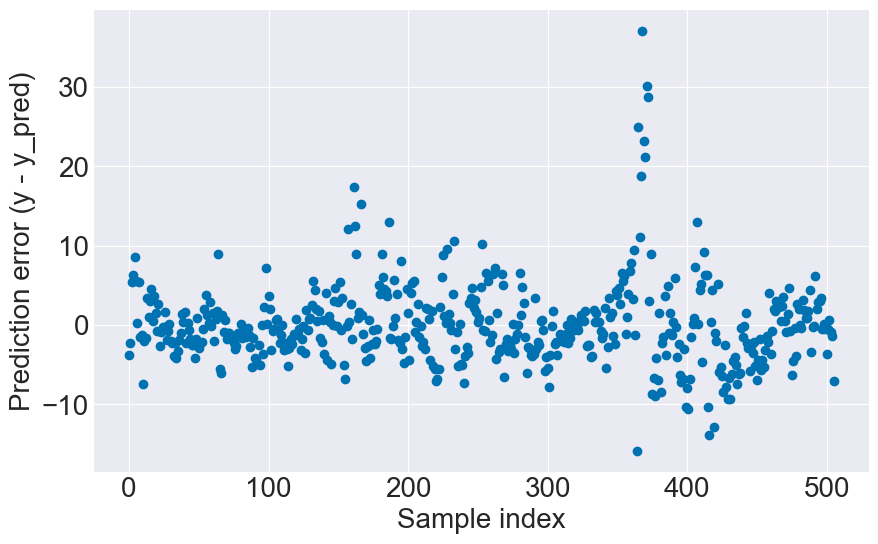

In [20]:
# YOUR CODE HERE
errors = y - y_pred
plt.figure(figsize=(10, 6))
plt.scatter(np.arange(len(y)), errors)
plt.xlabel("Sample index")
plt.ylabel("Prediction error (y - y_pred)")
plt.show()

## Task L3: Computing the matrix condition number

To help us interpret the results of the next task in relation to the linear regression you fit in the previous task, we will compute the matrix condition number of your $A$ matrix:

$$
\kappa = ||A|| * ||A^{-1}||
$$

_Recall: A matrix condition number of 1 corresponds to the ideal case where the original vector lengths in $A$ are exactly recovered after performing $Ac = y$ and performing the inverse operation. Larger values indicate that there are errors in the recovered vectors lengths._

1. In the cell below, copy-and-paste your code from Task L2 that produces the original $A$ matrix with the intercept column. Shape should be: `(506, 12)`


In [21]:
# YOUR CODE HERE
n_samples = data.shape[0]
A = np.hstack([np.ones((n_samples, 1)), data[:, :-1]])
print(A.shape)

(506, 12)


2. Compute $||A||$ below and assign the result to a variable `A_norm`. This is the [Frobenius norm](https://mathworld.wolfram.com/FrobeniusNorm.html) of the $A$ matrix, which is a single float that represents the square root of the sum of the squares of every entry in the $A$ matrix. Print out `A_norm` below, it should be `~10110`.


In [22]:
# YOUR CODE HERE
A_norm = np.linalg.norm(A)
print(A_norm)

10110.038791706656


### The pseudoinverse

Next, we are going to compute the rightmost term of $\kappa$, which involves the inverse of $A$. The trouble is, however, that we cannot compute the "regular" inverse of $A$ because $A$ is not a square matrix — it has shape `(506, 12)`)!

While we cannot _exactly_ compute $A^{-1}$ for rectangular $A$, we can compute a matrix $A^+$ that acts in the same way as the regular inverse $A^{-1}$:

$$
AA^{+} \approx I
$$

That is, when we multiply $A$ (shape: `(N, M+1)`) with this new matrix $A^+$ (shape: `(M+1, N)`), we get _very close_ to the identity matrix (shape: `(N, N)`). Because $A^+$ acts like $A^{-1}$, but it's not exactly the inverse, we call it the **pseudoinverse**. We will use the pseudoinverse to compute $||A^{-1}||$ in the equation for the matrix condition number $\kappa$ — i.e. we will compute $||A^{+}||$.

### Back to computing the rightmost term of $\kappa$

We can use the QR decomposition of $A$ to compute the pseudoinverse $||A^{+}||$! As we showed in class, $||A^{+}|| = ||R^{-1}||$ (where $R$ is the square upper triangular matrix from $A=QR$).

3. Use [np.linalg.qr](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html#numpy.linalg.qr) to compute the QR decomposition of $A$.
4. Take the regular inverse of $R$. Assign the output to the variable `A_plus` (this is $A^{+}$).
5. Repeat what you did above to compute the square root of the sum of squares of every element in `A_plus`. This is $||A^{+}||$. If everything is working properly, you should get `~1.289`.


In [23]:
# YOUR CODE HERE
Q, R = np.linalg.qr(A)
A_plus = np.linalg.inv(R)
A_plus_norm = np.linalg.norm(A_plus)
print(A_plus_norm)

1.289589465782193


6. Compute and print out the condition number of $A$ by multiplying the floats you obtained above for $||A||$ and $||A^{+}||$. You should obtain `~13037` if everything is working as expected.


In [24]:
# YOUR CODE HERE
kappa = A_norm * A_plus_norm
print(kappa)

13037.799524434235


7. To automate the computation of the condition number $\kappa$ in the next task, copy-and-paste the code that you wrote above into the function below. Executing the cell below should give you the same `~13037` condition number that you obtained above.


In [28]:
def cond_num(A):
    A_norm = np.linalg.norm(A)
    Q, R = np.linalg.qr(A)
    A_plus = np.linalg.inv(R)
    A_plus_norm = np.linalg.norm(A_plus)
    kappa = A_norm * A_plus_norm
    return kappa

# YOUR CODE HERE

print(cond_num(A))

13037.799524434235


## Task L4: Polynomial linear regression on the housing data

Look back at the MSE and scatter plot of prediction errors you made in Task L2. Let's try and improve on the fit with polynomial regression. Specifically, let's predict the house prices not just based on the original independent variables, but also by their squares. This means our $A$ matrix should now look like this:

$$
[\vec{1}, \vec{x_1}, \vec{x_2}, ..., \vec{x_M}, \vec{x_1}^2, \vec{x_2}^2, ..., \vec{x_M}^2]
$$

_This is a generalization of what we learned about in class and in the project because we are performing polynomial regression with >1 independent variable now._

1. Repeat what you did in Task L2, but first create a modified $A$ matrix with the added quadratic variables. _To accomplish this quickly with minimal code changes, I suggest first creating a new `A2` matrix that contains only the squares of the independent variables (without the intercept!). Then insert it on the right side of the list of items that you have `np.hstack` concatenate. This should require VERY little code changes since `np.hstack` allows you to "glue together" any number of ndarrays, regardless of how many columns they have!_ Here is a reminder of the components of the analysis in Task L2 that you should repeat here:
   1. Use Normal Equations to solve for the unknown coefficients using the modified $A$ matrix (with the intercept, original independent vars and their squares).
   2. Compute $\vec{y}_{pred}$ and MSE. Print the MSE.
   3. Create a scatter plot showing the error in the predictions for each sample.
   4. Call your `cond_num` function to compute the matrix condition number of the modified $A$ matrix. Print the condition number.


6.1217826246981875e+26


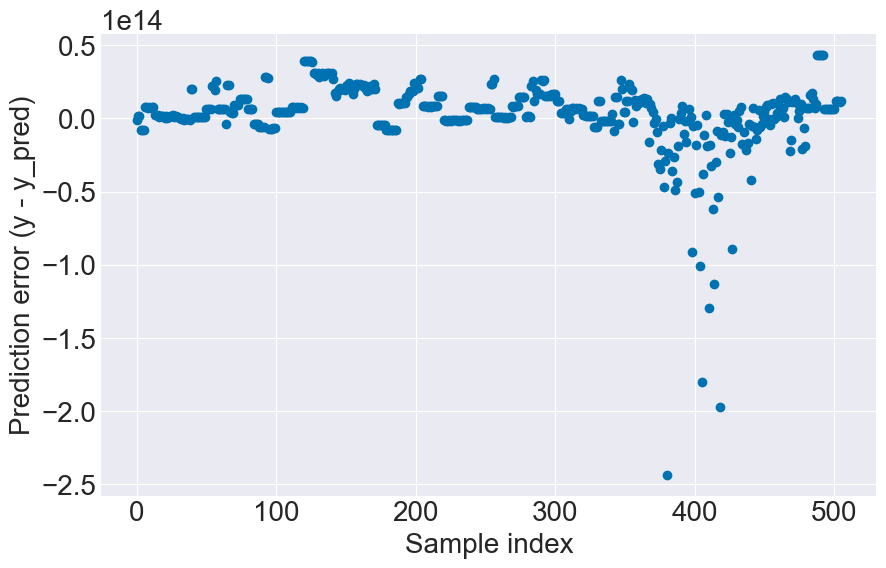

2.0376484585837043e+22


In [29]:
# YOUR CODE HERE
X = data[:, :-1]
A2 = X ** 2
n_samples = X.shape[0]
A_poly = np.hstack([np.ones((n_samples, 1)), X, A2])

At = A_poly.T
AtA = At @ A_poly
invAtA = np.linalg.inv(AtA)
c_poly = invAtA @ At @ y

y_pred_poly = A_poly @ c_poly
mse_poly = np.mean((y - y_pred_poly) ** 2)
print(mse_poly)

errors_poly = y - y_pred_poly
plt.figure(figsize=(10, 6))
plt.scatter(np.arange(len(y)), errors_poly)
plt.xlabel("Sample index")
plt.ylabel("Prediction error (y - y_pred)")
plt.show()

print(cond_num(A_poly))

**Question 1:** Compared to the MSE that you obtained in Task L2 with the "regular" linear regression, does the MSE here match what our expectations should be for a more complex linear regression model with many more variables (_HINT: Think about how MSE SHOULD trend when overfitting_)?

**Question 2:** Note/compare the matrix condition numbers you obtained in Task L2 and the one you obtained here. How do they differ?


**Answer 1:**


Yes. With a more complex model, training MSE should stay the same or decrease due to overfitting. If the MSE explodes, that indicates numerical instability rather than expected overfitting behavior.


**Answer 2:**


The polynomial feature matrix has a much larger condition number (orders of magnitude higher) than the original one, so it is far more ill-conditioned and numerically unstable.


## Task L5: Repeat polynomial regression using QR-based solver

Let's replicate the steps performed in Task L4, but this time use the QR-based least squares solver instead of the Normal Equations.

1. Copy-paste all your code from Task L4 below. This involves:
   1. Setting up the polynomial regression with modified A matrix with intercept, linear variables, and quadratic variables
   2. Computing $\vec{y}_{pred}$ and printing MSE
   3. Making the scatter plot of predictions
   4. Printing out condition number.
2. Modify your code to use QR decomposition to solve for the unknown coefficients $\vec{c}$ instead of the Normal Equations.
   1. Use [np.linalg.qr](https://numpy.org/doc/stable/reference/generated/numpy.linalg.qr.html#numpy.linalg.qr) to compute the `Q` and `R` matrices of the modified $A$ matrix.
   2. Compute $\vec{c}$ by calling `scipy.linalg.solve_triangular` and passing in $R$ as the first parameter and $Q^T\vec{y}$ as the second parameter.


23.860674770692086


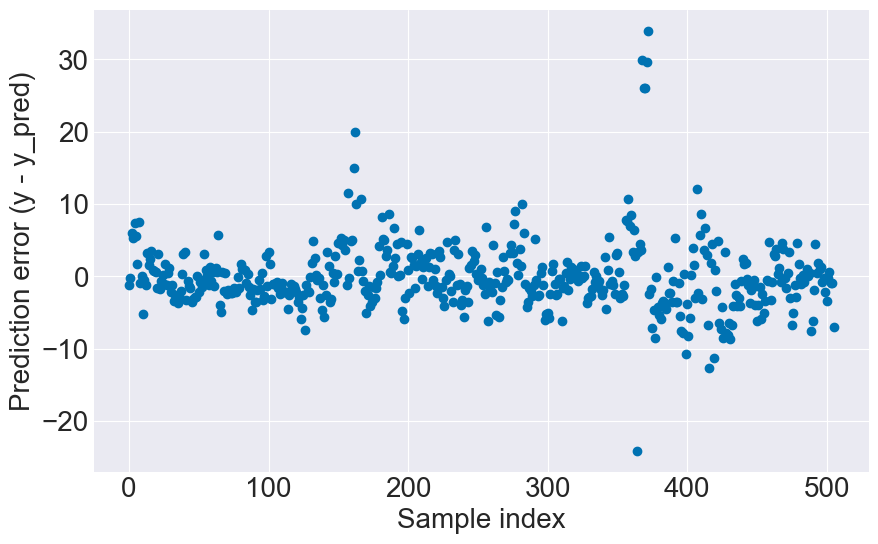

2.0376484585837043e+22


In [30]:
# YOUR CODE HERE
X = data[:, :-1]
A2 = X ** 2
n_samples = X.shape[0]
A_poly = np.hstack([np.ones((n_samples, 1)), X, A2])

Q, R = np.linalg.qr(A_poly)
c_qr = scipy.linalg.solve_triangular(R, Q.T @ y)

y_pred_qr = A_poly @ c_qr
mse_qr = np.mean((y - y_pred_qr) ** 2)
print(mse_qr)

errors_qr = y - y_pred_qr
plt.figure(figsize=(10, 6))
plt.scatter(np.arange(len(y)), errors_qr)
plt.xlabel("Sample index")
plt.ylabel("Prediction error (y - y_pred)")
plt.show()

print(cond_num(A_poly))

**Question 3:** Compare the MSE and prediction error plots obtained with QR decomposition and those obtained in the previous task using the Normal Equations. Do the results now match your expectations?


**Question 4:** Which least squares solver is more stable when operating on inputs with higher matrix condition numbers?


**Answer 3:**


Yes. With QR the MSE and error plot look reasonable and are lower than the unstable normal-equation result, which matches expectations for a more robust solver on ill-conditioned data.


**Answer 4:**


The QR-based solver is more stable for high condition numbers.


## Turn in your lab on Google Classroom
